<a href="https://colab.research.google.com/github/seonghg/GPU-Thermal-Behavior-under-AI-Workloads/blob/main/GPU_Thermal_Behavior_under_AI_Workloads.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

1. Parmeter Definition Parts

In [ ]:
def get_default_params():
    params = {
        # Simulation
        "dt": 0.01,          # second
        "t_end": 20.0,       # second

        # Initial / Ambient Temperature
        "T_init": 25.0,      # degree C
        "T_amb": 25.0,       # degree C

        # Thermal Model Parameters
        "R_th": 0.15,        # K/W
        "C_th": 50.0,        # J/K

        # Power Model Parameters
        "P_idle": 80.0,      # W
        "alpha": 120.0,      # W contribution of non-tensor SM activity
        "beta": 90.0,        # W contribution of memory activity
        "gamma": 180.0,      # W contribution of tensor activity
    }
    return params

2. Workload Definition
 - Constant
 - Burst
 - Phase bassed

In [ ]:
def workload_constant(t):
    """
    Constant workload:
    Fixed normalized utilization values in [0, 1]
    """
    u_sm_non_tensor = 0.40
    u_mem = 0.35
    u_tensor = 0.45
    return u_sm_non_tensor, u_mem, u_tensor


def workload_burst(t):
    """
    Burst workload:
    Alternates between low-load and high-load every 2 seconds
    """
    period = 4.0
    local_t = t % period

    if local_t < 2.0:
        # low-load phase
        u_sm_non_tensor = 0.20
        u_mem = 0.25
        u_tensor = 0.15
    else:
        # high-load phase
        u_sm_non_tensor = 0.75
        u_mem = 0.60
        u_tensor = 0.85

    return u_sm_non_tensor, u_mem, u_tensor


def workload_phase_based(t):
    """
    Phase-based workload:
    Repeats compute-heavy -> memory-heavy -> tensor-heavy phases
    """
    period = 9.0
    local_t = t % period

    if local_t < 3.0:
        # compute-heavy phase
        u_sm_non_tensor = 0.80
        u_mem = 0.30
        u_tensor = 0.20
    elif local_t < 6.0:
        # memory-heavy phase
        u_sm_non_tensor = 0.25
        u_mem = 0.85
        u_tensor = 0.20
    else:
        # tensor-heavy phase
        u_sm_non_tensor = 0.20
        u_mem = 0.35
        u_tensor = 0.90

    return u_sm_non_tensor, u_mem, u_tensor


def get_workload_function(workload_type):
    workload_map = {
        "constant": workload_constant,
        "burst": workload_burst,
        "phase": workload_phase_based,
    }

    if workload_type not in workload_map:
        raise ValueError(f"Unsupported workload type: {workload_type}")

    return workload_map[workload_type]

3. Calculate Model
 - Power model $$
P(t) = P_{\text{idle}} + \alpha \cdot u_{\text{sm_non_tensor}} + \beta \cdot u_{\text{mem}} + \gamma \cdot u_{\text{tensor}}
$$
 - Thermal model (Forward Eular)
 $$
T_{t+1} = T_t + \Delta t \cdot \frac{P(t) - \frac{T_t - T_{\text{amb}}}{R_{\text{th}}}}{C_{\text{th}}}
$$

In [ ]:
def power_model(u_sm_non_tensor, u_mem, u_tensor, params):
    """
    P(t) = P_idle + alpha*u_sm_non_tensor + beta*u_mem + gamma*u_tensor
    """
    P_idle = params["P_idle"]
    alpha = params["alpha"]
    beta = params["beta"]
    gamma = params["gamma"]

    P = P_idle + alpha * u_sm_non_tensor + beta * u_mem + gamma * u_tensor
    return P

def thermal_update(T, P, params):
    """
    Forward Euler update for:
    C_th * dT/dt = P(t) - (T - T_amb)/R_th
    """
    dt = params["dt"]
    C_th = params["C_th"]
    R_th = params["R_th"]
    T_amb = params["T_amb"]

    dTdt = (P - (T - T_amb) / R_th) / C_th
    T_next = T + dt * dTdt
    return T_next

4. Simulation

In [ ]:
def run_simulation(params, workload_type="constant"):
    times = np.arange(0, params["t_end"] + params["dt"], params["dt"])
    workload_fn = get_workload_function(workload_type)

    T = params["T_init"]

    temperature_list = []
    power_list = []
    u_sm_list = []
    u_mem_list = []
    u_tensor_list = []

    for t in times:
        u_sm_non_tensor, u_mem, u_tensor = workload_fn(t)
        P = power_model(u_sm_non_tensor, u_mem, u_tensor, params)
        T = thermal_update(T, P, params)

        u_sm_list.append(u_sm_non_tensor)
        u_mem_list.append(u_mem)
        u_tensor_list.append(u_tensor)
        power_list.append(P)
        temperature_list.append(T)

    results = {
        "time": times,
        "u_sm_non_tensor": np.array(u_sm_list),
        "u_mem": np.array(u_mem_list),
        "u_tensor": np.array(u_tensor_list),
        "power": np.array(power_list),
        "temperature": np.array(temperature_list),
    }
    return results

5. Analysis Utilities & Visualization

In [ ]:
def compute_steady_state_temperature(power_value, params):
    """
    For constant power:
    T_ss = T_amb + P * R_th
    """
    return params["T_amb"] + power_value * params["R_th"]


def print_simulation_summary(results, params, workload_type):
    power_avg = np.mean(results["power"])
    temp_max = np.max(results["temperature"])
    temp_final = results["temperature"][-1]
    tau = params["R_th"] * params["C_th"]

    print(f"\n=== Simulation Summary: {workload_type} ===")
    print(f"Average Power      : {power_avg:.2f} W")
    print(f"Final Temperature  : {temp_final:.2f} °C")
    print(f"Peak Temperature   : {temp_max:.2f} °C")
    print(f"Thermal Time Const.: {tau:.2f} s")

    if workload_type == "constant":
        t_ss = compute_steady_state_temperature(power_avg, params)
        print(f"Estimated Steady-State Temperature: {t_ss:.2f} °C")

def plot_workload(results, title_suffix=""):
    plt.figure(figsize=(10, 4))
    plt.plot(results["time"], results["u_sm_non_tensor"], label="u_sm_non_tensor")
    plt.plot(results["time"], results["u_mem"], label="u_mem")
    plt.plot(results["time"], results["u_tensor"], label="u_tensor")
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized Utilization")
    plt.title(f"Workload Activity Over Time {title_suffix}")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_power(results, title_suffix=""):
    plt.figure(figsize=(10, 4))
    plt.plot(results["time"], results["power"])
    plt.xlabel("Time (s)")
    plt.ylabel("Power (W)")
    plt.title(f"Power Over Time {title_suffix}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_temperature(results, title_suffix=""):
    plt.figure(figsize=(10, 4))
    plt.plot(results["time"], results["temperature"])
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature Over Time {title_suffix}")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_all(results, workload_type=""):
    title_suffix = f"({workload_type})" if workload_type else ""

    plot_workload(results, title_suffix=title_suffix)
    plot_power(results, title_suffix=title_suffix)
    plot_temperature(results, title_suffix=title_suffix)



=== Simulation Summary: phase ===
Average Power      : 251.59 W
Final Temperature  : 60.70 °C
Peak Temperature   : 60.70 °C
Thermal Time Const.: 7.50 s


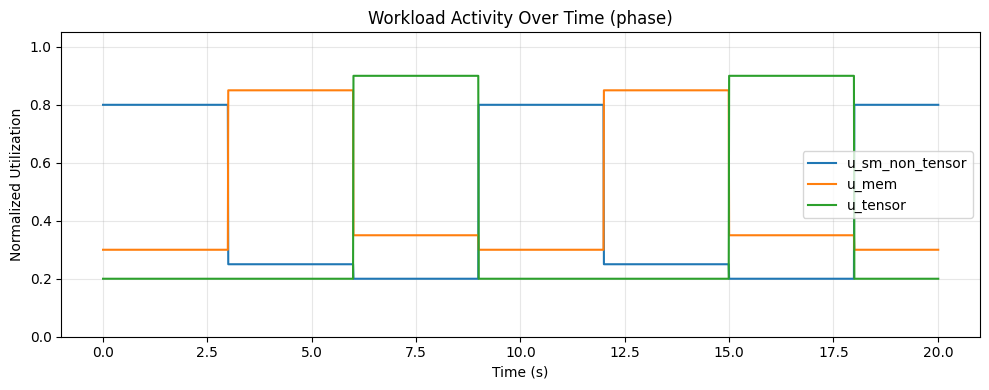

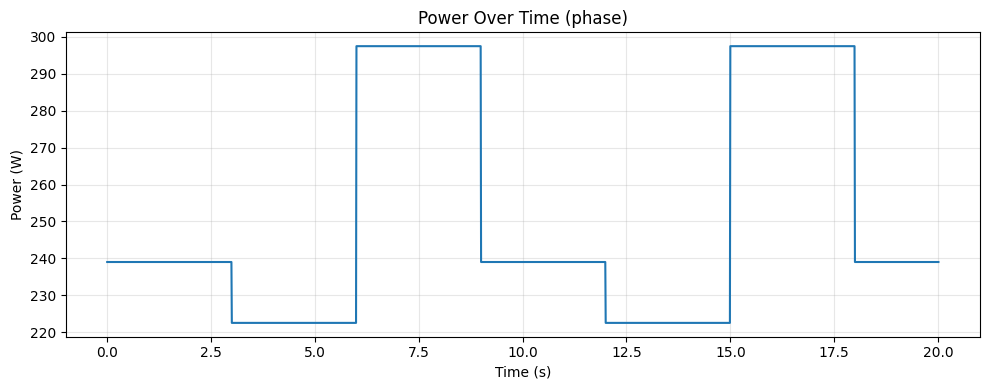

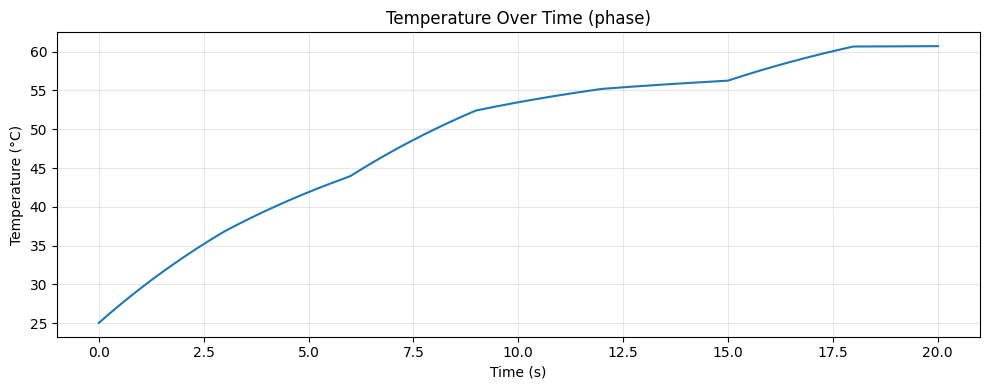

In [ ]:
def main():
    params = get_default_params()

    # Choose one: "constant", "burst", "phase"
    workload_type = "phase"

    results = run_simulation(params, workload_type=workload_type)
    print_simulation_summary(results, params, workload_type)
    plot_all(results, workload_type=workload_type)


if __name__ == "__main__":
    main()